In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import seaborn as sns
sns.set_style("darkgrid")

import warnings
warnings.filterwarnings("ignore")


%config InlineBackend.figure_format = "svg"

In [59]:
from prophet import Prophet

In [60]:
df = pd.read_csv(".\\UDEMY_TSA_FINAL\\UDEMY_TSA_FINAL\\Data\\BeerWineLiquor.csv" )
df

,date,beer
0,1/1/1992,1509
1,2/1/1992,1541
2,3/1/1992,1597
3,4/1/1992,1675
4,5/1/1992,1822
...,...,...
319,8/1/2018,4898
320,9/1/2018,4598
321,10/1/2018,4737
322,11/1/2018,5130


In [61]:
df.columns = ["ds" , "y"] # ds: data stamp , 
df["ds"] = df["ds"].astype("datetime64[ns]") 
#df["ds"] = pd.to_datetime(df["ds"])

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      324 non-null    datetime64[ns]
 1   y       324 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.2 KB


In [63]:
model = Prophet()
model.fit(df)

10:49:29 - cmdstanpy - INFO - Chain [1] start processing
10:49:29 - cmdstanpy - INFO - Chain [1] done processing


In [64]:
df.iloc[-12:]

,ds,y
312,2018-01-01,3965
313,2018-02-01,3967
314,2018-03-01,4629
315,2018-04-01,4317
316,2018-05-01,4897
317,2018-06-01,4939
318,2018-07-01,4963
319,2018-08-01,4898
320,2018-09-01,4598
321,2018-10-01,4737


In [65]:
future = model.make_future_dataframe(periods=24 ,freq="MS")
future

,ds
0,1992-01-01
1,1992-02-01
2,1992-03-01
3,1992-04-01
4,1992-05-01
...,...
343,2020-08-01
344,2020-09-01
345,2020-10-01
346,2020-11-01


In [66]:
future.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      348 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.8 KB


In [67]:
future.iloc[-36:]

,ds
312,2018-01-01
313,2018-02-01
314,2018-03-01
315,2018-04-01
316,2018-05-01
317,2018-06-01
318,2018-07-01
319,2018-08-01
320,2018-09-01
321,2018-10-01


In [68]:
forecast = model.predict(future)
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [69]:
forecast[["ds", "yhat_lower", "yhat_upper" , "yhat"]]

,ds,yhat_lower,yhat_upper,yhat
0,1992-01-01,1137.989197,1462.416832,1302.445544
1,1992-02-01,1169.095205,1502.562021,1340.499281
2,1992-03-01,1427.480662,1753.465419,1591.380524
3,1992-04-01,1419.000374,1741.846191,1576.939880
4,1992-05-01,1648.792086,1988.597659,1820.813610
...,...,...,...,...
343,2020-08-01,5087.440352,5403.559021,5239.079018
344,2020-09-01,4916.093829,5237.544179,5081.918552
345,2020-10-01,5014.198672,5354.171850,5187.707688
346,2020-11-01,5166.323410,5500.742109,5335.102931


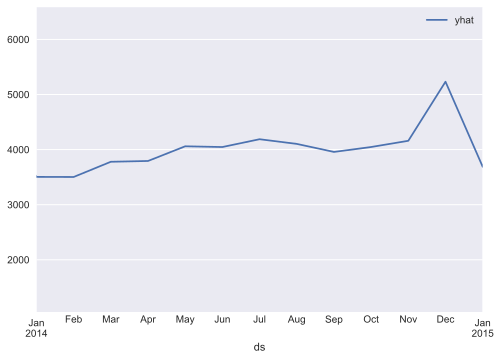

In [70]:
forecast.plot(x = "ds", y = "yhat")
plt.xlim("2014","2015")
plt.show()

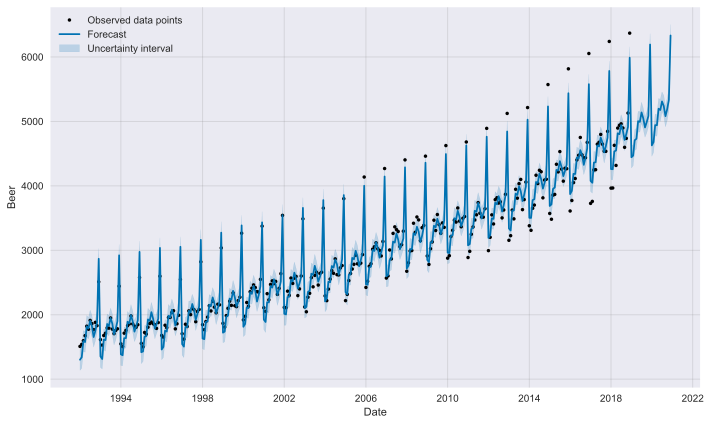

In [71]:
model.plot(fcst = forecast, include_legend=True , uncertainty=True, xlabel="Date", ylabel="Beer")
plt.show()

In [72]:
pd.Timestamp("2014-01-01")

Timestamp('2014-01-01 00:00:00')

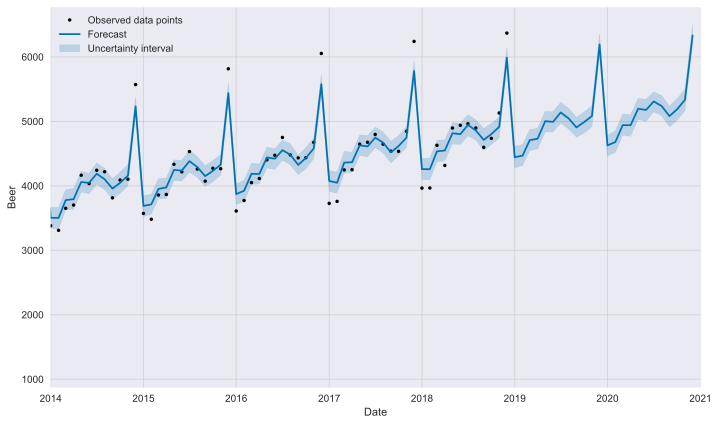

In [73]:
model.plot(fcst = forecast, include_legend=True , uncertainty=True, xlabel="Date", ylabel="Beer")
plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2021-01-01"))
plt.show()

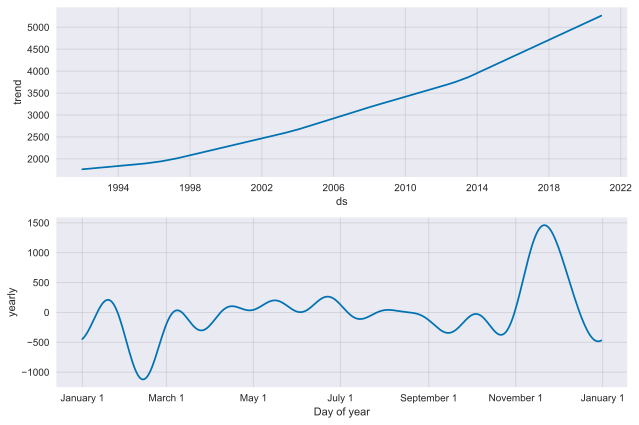

In [74]:
model.plot_components(fcst = forecast)
plt.show()

## Train & Test Split

In [75]:
len(df)

324

In [76]:
splitter = int(len(df) * 0.8)
splitter

259

In [77]:
train = df.iloc[:splitter]
test = df.iloc[splitter:]

In [78]:
new_model = Prophet()
new_model.fit(train)
new_future = new_model.make_future_dataframe(periods=len(test) , freq = "MS")
new_forecast = new_model.predict(new_future)
new_forecast.head()

10:49:31 - cmdstanpy - INFO - Chain [1] start processing
10:49:31 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1992-01-01,1792.093380,1240.479034,1502.539358,1792.093380,1792.093380,-419.109336,-419.109336,-419.109336,-419.109336,-419.109336,-419.109336,0.0,0.0,0.0,1372.984044
1,1992-02-01,1793.992138,1276.698006,1541.606230,1793.992138,1793.992138,-382.435467,-382.435467,-382.435467,-382.435467,-382.435467,-382.435467,0.0,0.0,0.0,1411.556671
2,1992-03-01,1795.768396,1498.013203,1759.791387,1795.768396,1795.768396,-167.000487,-167.000487,-167.000487,-167.000487,-167.000487,-167.000487,0.0,0.0,0.0,1628.767909
3,1992-04-01,1797.667154,1488.290589,1748.234115,1797.667154,1797.667154,-184.806527,-184.806527,-184.806527,-184.806527,-184.806527,-184.806527,0.0,0.0,0.0,1612.860627
4,1992-05-01,1799.504662,1712.630652,1975.593295,1799.504662,1799.504662,48.554807,48.554807,48.554807,48.554807,48.554807,48.554807,0.0,0.0,0.0,1848.059469


In [79]:
new_forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
319,2018-08-01,4357.931135,4230.222644,4533.250527,4281.658541,4430.235559,22.459169,22.459169,22.459169,22.459169,22.459169,22.459169,0.0,0.0,0.0,4380.390305
320,2018-09-01,4367.149235,4112.806555,4417.818160,4289.373824,4441.550914,-101.724541,-101.724541,-101.724541,-101.724541,-101.724541,-101.724541,0.0,0.0,0.0,4265.424694
321,2018-10-01,4376.069977,4182.356629,4480.117388,4296.565681,4451.900461,-47.725183,-47.725183,-47.725183,-47.725183,-47.725183,-47.725183,0.0,0.0,0.0,4328.344794
322,2018-11-01,4385.288077,4260.965633,4568.601378,4302.865197,4463.030417,34.337568,34.337568,34.337568,34.337568,34.337568,34.337568,0.0,0.0,0.0,4419.625646
323,2018-12-01,4394.208819,5243.314864,5542.627720,4309.930988,4473.627630,999.418277,999.418277,999.418277,999.418277,999.418277,999.418277,0.0,0.0,0.0,5393.627097


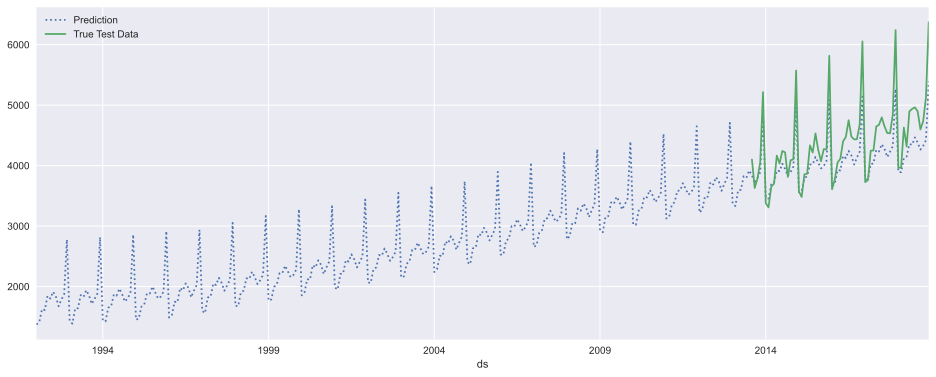

In [80]:
ax = new_forecast.plot(x = "ds" , y = "yhat" , label = "Prediction", legend = True , figsize=(16,6), ls = ":")
test.plot(x = "ds" , y ="y", label = "True Test Data" , legend = True , ax = ax )

plt.show()

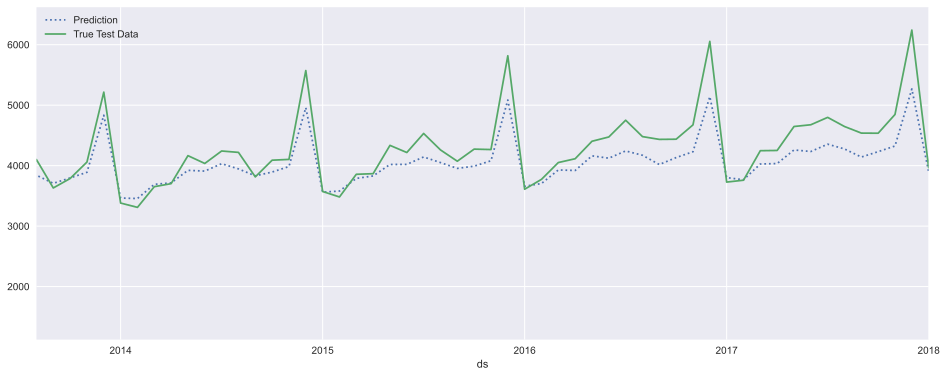

In [81]:
ax = new_forecast.plot(x = "ds" , y = "yhat" , label = "Prediction", legend = True , figsize=(16,6), ls = ":")
test.plot(x = "ds" , y ="y", label = "True Test Data" , legend = True , ax = ax )
plt.xlim("2013-08-01","2018")
plt.show()

Prophet Evaluation metrics:

In [82]:
from statsmodels.tools.eval_measures import rmse

In [83]:
test

,ds,y
259,2013-08-01,4100
260,2013-09-01,3631
261,2013-10-01,3787
262,2013-11-01,4059
263,2013-12-01,5215
...,...,...
319,2018-08-01,4898
320,2018-09-01,4598
321,2018-10-01,4737
322,2018-11-01,5130


In [84]:
new_forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1992-01-01,1792.093380,1240.479034,1502.539358,1792.093380,1792.093380,-419.109336,-419.109336,-419.109336,-419.109336,-419.109336,-419.109336,0.0,0.0,0.0,1372.984044
1,1992-02-01,1793.992138,1276.698006,1541.606230,1793.992138,1793.992138,-382.435467,-382.435467,-382.435467,-382.435467,-382.435467,-382.435467,0.0,0.0,0.0,1411.556671
2,1992-03-01,1795.768396,1498.013203,1759.791387,1795.768396,1795.768396,-167.000487,-167.000487,-167.000487,-167.000487,-167.000487,-167.000487,0.0,0.0,0.0,1628.767909
3,1992-04-01,1797.667154,1488.290589,1748.234115,1797.667154,1797.667154,-184.806527,-184.806527,-184.806527,-184.806527,-184.806527,-184.806527,0.0,0.0,0.0,1612.860627
4,1992-05-01,1799.504662,1712.630652,1975.593295,1799.504662,1799.504662,48.554807,48.554807,48.554807,48.554807,48.554807,48.554807,0.0,0.0,0.0,1848.059469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,2018-08-01,4357.931135,4230.222644,4533.250527,4281.658541,4430.235559,22.459169,22.459169,22.459169,22.459169,22.459169,22.459169,0.0,0.0,0.0,4380.390305
320,2018-09-01,4367.149235,4112.806555,4417.818160,4289.373824,4441.550914,-101.724541,-101.724541,-101.724541,-101.724541,-101.724541,-101.724541,0.0,0.0,0.0,4265.424694
321,2018-10-01,4376.069977,4182.356629,4480.117388,4296.565681,4451.900461,-47.725183,-47.725183,-47.725183,-47.725183,-47.725183,-47.725183,0.0,0.0,0.0,4328.344794
322,2018-11-01,4385.288077,4260.965633,4568.601378,4302.865197,4463.030417,34.337568,34.337568,34.337568,34.337568,34.337568,34.337568,0.0,0.0,0.0,4419.625646


In [85]:
rmse(new_forecast["yhat"].iloc[- len(test["y"]):] , test["y"])

376.98258974814917

### Cross Validation & Performance Metrics
https://facebook.github.io/prophet/docs/diagnostics.html

In [86]:
from prophet.diagnostics import cross_validation , performance_metrics

In [87]:
# Initial
initial = 5 * 365
initial = str(initial) +' ' + 'days' 
initial

'1825 days'

In [88]:
# Period

period = 5 * 365
period = str(period) + ' ' + 'days'
period

'1825 days'

In [89]:
# Horizon
horizon = 365
horizon = str(horizon) + ' ' + 'days'
horizon

'365 days'

In [90]:
df_cv = cross_validation(model=model , horizon=horizon , period=period , initial=initial)


  0%|          | 0/5 [00:00<?, ?it/s]

10:49:32 - cmdstanpy - INFO - Chain [1] start processing
10:49:32 - cmdstanpy - INFO - Chain [1] done processing
10:49:32 - cmdstanpy - INFO - Chain [1] start processing
10:49:32 - cmdstanpy - INFO - Chain [1] done processing
10:49:32 - cmdstanpy - INFO - Chain [1] start processing
10:49:32 - cmdstanpy - INFO - Chain [1] done processing
10:49:32 - cmdstanpy - INFO - Chain [1] start processing
10:49:32 - cmdstanpy - INFO - Chain [1] done processing
10:49:33 - cmdstanpy - INFO - Chain [1] start processing
10:49:33 - cmdstanpy - INFO - Chain [1] done processing


In [91]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1998-01-01,1812.535409,1762.928518,1865.427344,1846,1997-12-06
1,1998-02-01,1759.795443,1708.295626,1813.056956,1768,1997-12-06
2,1998-03-01,1946.273004,1897.605153,2001.523725,1894,1997-12-06
3,1998-04-01,1958.984994,1910.308898,2011.996444,1963,1997-12-06
4,1998-05-01,2085.447996,2035.093511,2135.669250,2140,1997-12-06


In [92]:
len(df_cv)

60

In [94]:
performance_metrics(df_cv)


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,57 days,40202.534816,200.505698,167.338483,0.058170,0.076151,0.056051,0.333333
1,58 days,48320.459522,219.819152,198.964481,0.073333,0.078466,0.070245,0.166667
2,59 days,46090.456731,214.686881,191.271447,0.067368,0.076151,0.064630,0.166667
3,61 days,38002.138935,194.941373,169.913129,0.058048,0.059006,0.055901,0.333333
4,62 days,42112.605764,205.213561,177.576567,0.057329,0.058414,0.055233,0.333333
5,85 days,27992.325685,167.309072,137.000989,0.049498,0.041124,0.047787,0.333333
6,86 days,32042.887783,179.005273,161.652086,0.060171,0.056054,0.058078,0.166667
7,88 days,28331.034991,168.318255,152.115478,0.051244,0.049482,0.049841,0.166667
8,89 days,25956.067135,161.108867,135.886424,0.045132,0.047179,0.043887,0.333333
9,90 days,25354.091410,159.229681,133.326886,0.042620,0.041568,0.041545,0.333333


In [93]:
from prophet.plot import plot_cross_validation_metric

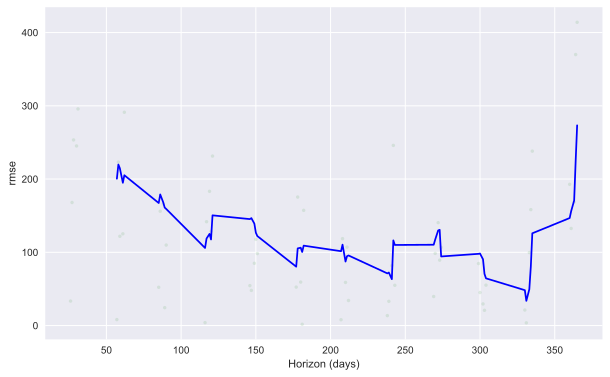

In [103]:
plot_cross_validation_metric(df_cv , metric='rmse', point_color='green');

### Prophet Trend

In [104]:
from prophet.plot import add_changepoints_to_plot

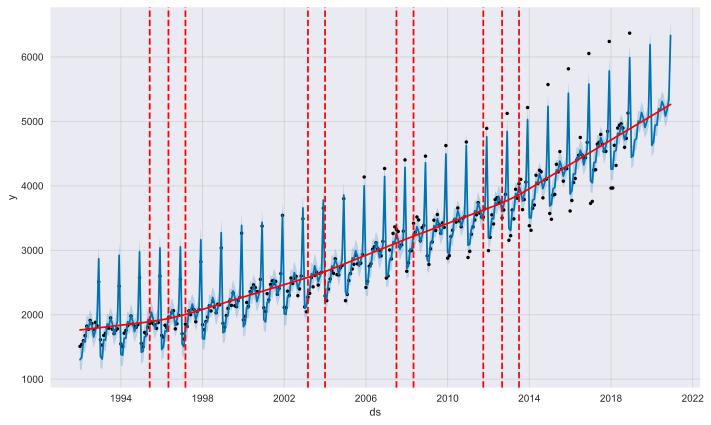

In [107]:
fig = model.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m = model , fcst=forecast)

### Prophet Seasonality

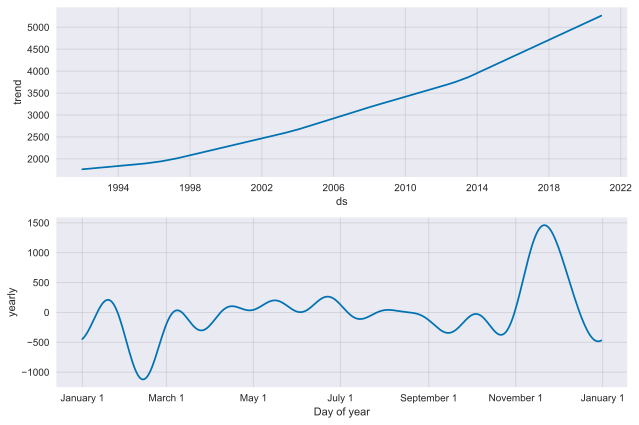

In [108]:
fig2 = model.plot_components(fcst = forecast)

In [110]:
### Multiplicative seasonality

In [111]:
model_mul = Prophet(seasonality_mode='multiplicative')
model_mul.fit(train)
future_mul = model_mul.make_future_dataframe(periods=len(test) , freq = "MS")
forecast_mul = model_mul.predict(future)
forecast_mul.head()

11:07:27 - cmdstanpy - INFO - Chain [1] start processing
11:07:27 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,1992-01-01,1782.624228,1415.848286,1571.149791,1782.624228,1782.624228,-0.163257,-0.163257,-0.163257,-0.163257,-0.163257,-0.163257,0.0,0.0,0.0,1491.597536
1,1992-02-01,1784.567834,1448.123257,1606.924103,1784.567834,1784.567834,-0.144160,-0.144160,-0.144160,-0.144160,-0.144160,-0.144160,0.0,0.0,0.0,1527.304718
2,1992-03-01,1786.386045,1595.028216,1751.231059,1786.386045,1786.386045,-0.064070,-0.064070,-0.064070,-0.064070,-0.064070,-0.064070,0.0,0.0,0.0,1671.932181
3,1992-04-01,1788.329651,1584.325065,1740.351222,1788.329651,1788.329651,-0.071464,-0.071464,-0.071464,-0.071464,-0.071464,-0.071464,0.0,0.0,0.0,1660.528077
4,1992-05-01,1790.210560,1751.089199,1908.571398,1790.210560,1790.210560,0.022038,0.022038,0.022038,0.022038,0.022038,0.022038,0.0,0.0,0.0,1829.663507


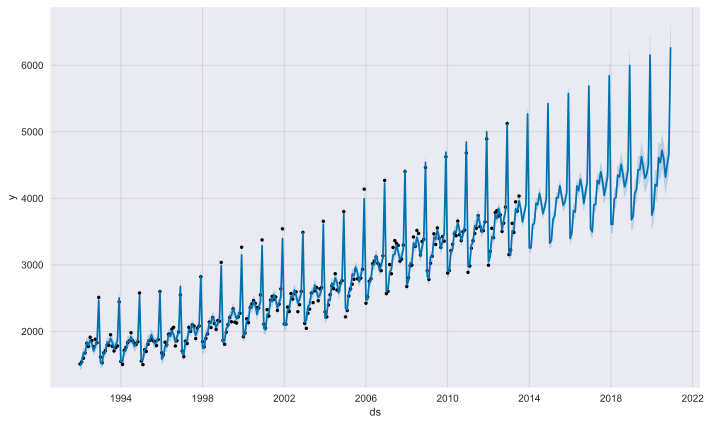

In [113]:
model_mul.plot(forecast_mul)
plt.show()

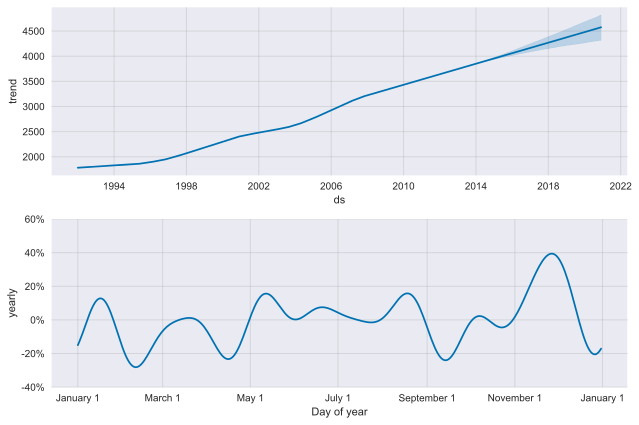

In [116]:
model_mul.plot_components(forecast_mul)
plt.show()